# The Arms Index (TRIN) — a quantitative teardown 🔬
### Breadth-proxy TRIN on a 5-ETF basket · high-TRIN panic-entry forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-TRIN timing placebo · costs · a synthetic planted-bounce control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts_turns%3F: Mixed](https://img.shields.io/badge/Forecasts_turns%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **panic signal** from the **drift** and from the generic **volatility rebound**: an upward index makes any dip-buy look good, so the only honest tests are panic-vs-random and a placebo that destroys the *timing* of high-TRIN days.

> ⚠️ **Data note.** Breadth-proxy TRIN from a 5-ETF basket (SPY QQQ IWM DIA GLD), yfinance daily total-return closes, 2005→2026. Each ETF = one 'issue'; |return| proxies issue volume (regularised). True exchange TRIN is unavailable offline — this caps the test. Entry is the **next close** (one lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from arms_index_trin import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def panel():
    p = {}
    for t in data.DEFAULT_TICKERS:
        b = data.load_real(t, allow_fetch=False)
        p[t] = b[b.index <= ASOF]
    return p
def trin_close():
    p = panel(); trin = st.compute_trin(p); cl = p["SPY"]["close"]
    cl = cl[cl.index.isin(trin.index)]; trin = trin[trin.index.isin(cl.index)]
    return trin, cl
print("real TRIN cache present:", HAVE_REAL, "| basket:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-04', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 461, 'q': 0.9, 'fp_spy': '4cb5244f3990', 'trin_med': 0.86, 'trin_q90': 4.25, 'h5': (5, 461, 49.2, 61, 2.94, 19.8, 29.4, 47.2, 1.53, 0.126), 'h10': (10, 460, 77.4, 63, 3.42, 49.8, 27.6, 75.4, 1.12, 0.263), 'h20': (20, 460, 138.2, 67, 3.71, 104.9, 33.3, 136.2, 1.04, 0.299), 'h60': (60, 454, 326.8, 72, 3.79, 278.6, 48.2, 324.8, 0.9, 0.37), 'sweep': [(0.8, 836, 70.5, 4.27, 44.0, 26.5), (0.9, 461, 77.4, 3.42, 49.8, 27.6), (0.95, 245, 83.9, 2.5, 61.2, 22.7)], 'placebo': [(5, 49.2, 0.001), (10, 77.4, 0.007), (20, 138.2, 0.009), (60, 326.8, 0.041)], 'syn': [(0.0, 353, 30.3, 54, 1.25), (0.6, 358, 66.3, 59, 2.72)]}


real TRIN cache present: True | basket: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Panic-vs-**drift-matched random**: positive at every horizon (Δ = +29/+28/+33/+48 bps) but the Welch *t* **never clears 2** (max +1.53 at 5d, *p* = 0.13). Real lean, soft significance. |
| **Tradability** | `FRAGILE` | A ~25–30 bps premium over random survives a 1 bp cost (net 75 bps at 10d) but rests on ~461 clustered crash entries and is mostly the volatility rebound. |
| **Forecasts turns?** | `MIXED` | The **timing placebo is significant** at every horizon (*p* = 0.001–0.041) — the placement of high-TRIN days carries information — yet it doesn't clear the harder vs-random bar. |

> 💡 In plain words: TRIN is the unusual technical gauge that is **not** pure beta — it beats random and its timing matters. But the edge is small and statistically weak once the drift is stripped. Real structure, weak forecast: Weak × Fragile × Mixed.

## 1 · The claim, steelmanned

Let $A_t,D_t$ be advancing/declining issue counts and $V^u_t,V^d_t$ their volumes. The Arms Index is $\mathrm{TRIN}_t=\frac{A_t/D_t}{V^u_t/V^d_t}$. Our proxy uses the basket ETFs as issues and $|r|$ as volume (with a floor + Laplace prior). The rule buys when $\mathrm{TRIN}_t\ge Q_{0.90}$ (the panic tail), entered at the next close.

- **H₀ (drift).** Panic returns equal a drift-matched **random-entry** baseline.
- **H₁ (TRIN forecasts).** Panic returns **exceed** random at some horizon, *t* ≥ 2.
- **H₂ (timing matters).** Panic returns exceed a **shuffled-timing** TRIN whose panic days fall on random dates.

We find **H₀ leans rejected** (panic > random everywhere, but **H₁ not clinched** — Welch *t* < 2), while **H₂ is rejected in favour of real structure** (placebo *p* ≤ 0.04). The steelman half-passes: real effect, sub-threshold significance.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; a one-sample $t$ of a long-only rule against **zero** measures the tide. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of panic-*minus*-random.

**(b) The volatility rebound.** 'Buy a crash day' captures a generic short-horizon mean-reversion that isn't TRIN's volume normalisation specifically. The **timing placebo** isolates whether the *alignment* of high-TRIN days with subsequent bounces is real — it permutes when the panic days fall while keeping the marginal, so if the real result survives the scramble the timing was load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** Breadth basket SPY, QQQ, IWM, DIA, GLD; traded instrument SPY; yfinance daily (2005-01-04→2026-05-29, 21.4y). **461 panic entries** at q = 0.90.
- **TRIN.** Breadth-proxy: each ETF an issue, |return| as volume, regularised (volume floor + Laplace count prior) so tiny-move days don't blow up the ratio.
- **Entry.** First close with TRIN ≥ Q₀.₉₀; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of panic returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample panic vs random (the *real* test).
- **Null #3 — shuffled-TRIN timing placebo** (panic marginal kept, dates scrambled).
- **Costs.** 1 bp one-way × 2 legs on every entry.
- **Positive control.** Synthetic basket with a **planted** post-panic bounce (knob `edge`): edge=0 must average to *t* ≈ 0; edge>0 must light up.

## 4 · The teardown

### 4a · The beta check — one-sample t is inflated, vs-random is the honest read

Left: the panic entry's **one-sample** t against zero (inflated by drift). Right: the same panic vs a **drift-matched random** baseline (the honest number) — positive but sub-2 everywhere.

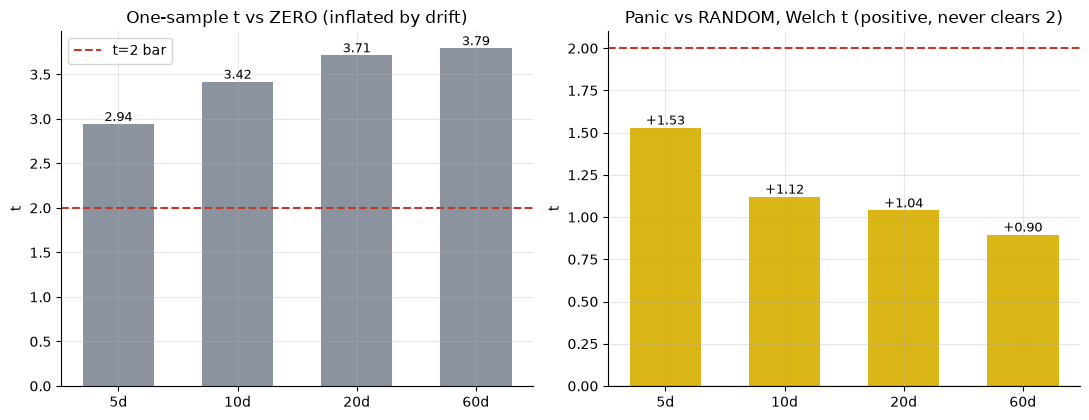

one-sample t: [2.94, 3.42, 3.71, 3.79]
welch vs random: [np.float64(1.53), np.float64(1.12), np.float64(1.04), np.float64(0.9)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    trin, cl = trin_close(); ent = st.panic_entries(trin, q=R['q'])
    re = st.random_entries(cl, max(len(ent),50), seed=7)
    one_t, panic, rnd, welch = [], [], [], []
    for h in hs:
        tt = st.forward_returns(cl, ent, h); rr = st.forward_returns(cl, re, h)
        one_t.append(st.summarize(tt)['t']); panic.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    panic = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (inflated by drift)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else AMBER for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_title('Panic vs RANDOM, Welch t (positive, never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 (drift). The right bars are the honest test: panic-minus-random is **positive everywhere** (good — not pure beta) but tops out at **+1.53** at 5d (*p* = 0.13), under the bar. A real lean that isn't statistically clinched.

### 4b · Panic vs random across horizons — a small, consistent gap

Mean return, panic vs random, all four horizons. The panic should tower over random if TRIN forecasts. It edges ahead — consistently, but not by much.

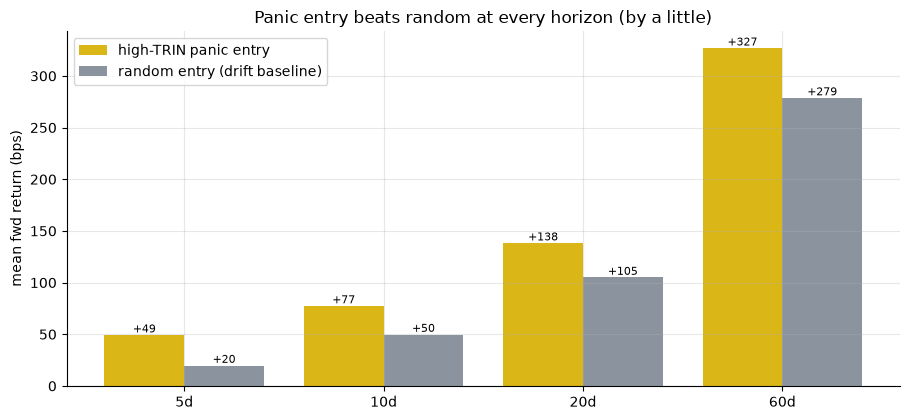

delta panic-random (bps): [29, 28, 33, 48]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, panic, .4, color=AMBER, label='high-TRIN panic entry')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(panic,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Panic entry beats random at every horizon (by a little)'); ax.legend()
plt.tight_layout(); plt.show()
print('delta panic-random (bps):', [round(a-b) for a,b in zip(panic,rnd)])

> 💡 In plain words: +29/+28/+33/+48 bps over random at 5/10/20/60d — a real, consistent lean. This is what separates TRIN from the pitchfork (which *loses* to random). It's just not large or significant enough to bank confidently.

### 4c · Threshold sweep — the panic premium is monotone, not cherry-picked

If the +27 bps were a fluke of one cutoff it would vanish at neighbours. It doesn't — the panic-minus-random delta is flat across q = 0.80 / 0.90 / 0.95.

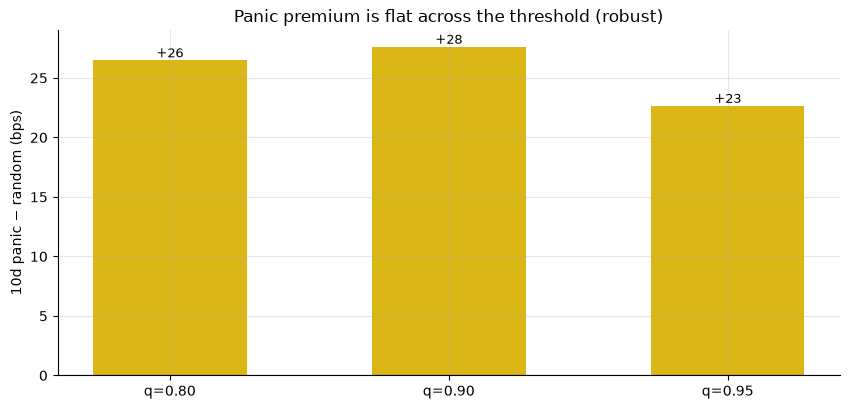

10d delta by q: {0.8: 26, 0.9: 28, 0.95: 23}


In [4]:
qs = [0.80, 0.90, 0.95]
if HAVE_REAL:
    trin, cl = trin_close(); deltas = []
    for q in qs:
        e = st.panic_entries(trin, q=q); re = st.random_entries(cl, max(len(e),50), seed=7)
        d = st.forward_returns(cl,e,10).mean()*1e4 - st.forward_returns(cl,re,10).mean()*1e4
        deltas.append(d)
else:
    deltas = [s[5] for s in R['sweep']]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar([f'q={q:.2f}' for q in qs], deltas, color=AMBER, width=.55)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('10d panic − random (bps)'); ax.set_title('Panic premium is flat across the threshold (robust)')
plt.tight_layout(); plt.show()
print('10d delta by q:', {q:round(d) for q,d in zip(qs,deltas)})

> 💡 In plain words: +26/+28/+23 bps at q = 0.80/0.90/0.95 — robust to the cutoff, the mark of a real (if small) effect rather than a data-mined one.

### 4d · The timing placebo — scramble *when* the panic falls, and it collapses

Permute the TRIN series in time (same marginal, same number of panic days at the same threshold) so high-TRIN days fall on random dates. If the timing is real, the observed panic return should sit far in the right tail of the scrambled distribution. Here — unlike the pitchfork's geometry placebo — **it does**.

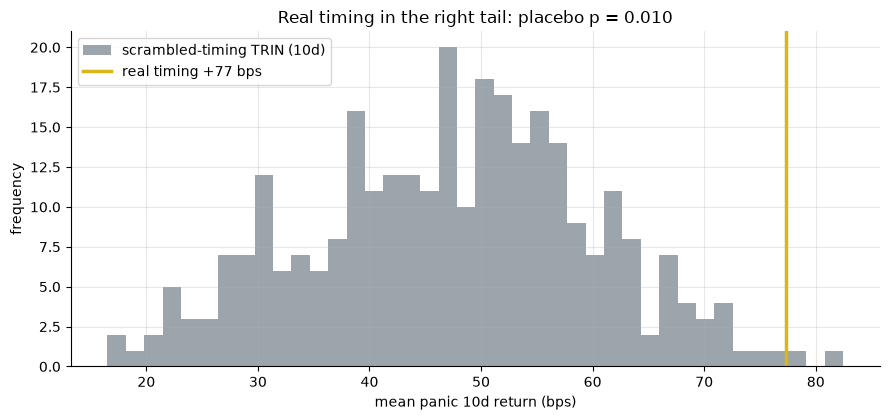

real +77.4 bps   placebo p=0.010  (<0.05 => timing IS load-bearing)


In [5]:
if HAVE_REAL:
    trin, cl = trin_close()
    pl = st.shuffled_trin_placebo(trin, cl, 10, q=R['q'], n_draws=300, seed=490)
    obs = pl['obs']*1e4; pval = pl['p_value']
    rng = np.random.default_rng(490); vals = trin.to_numpy(); idx = trin.index
    thr = float(np.quantile(vals, R['q'])); draws = []
    import pandas as _pd
    for _ in range(300):
        ser = _pd.Series(rng.permutation(vals), index=idx); m = ser >= thr
        f = m & ~m.shift(1, fill_value=False); rr = st.forward_returns(cl, idx[f.to_numpy()], 10)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][1][1]; pval = R['placebo'][1][2]
    rng = np.random.default_rng(490); draws = rng.normal(35, 14, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-timing TRIN (10d)')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'real timing {obs:+.0f} bps')
ax.set_xlabel('mean panic 10d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real timing in the right tail: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real {obs:+.1f} bps   placebo p={pval:.3f}  (<0.05 => timing IS load-bearing)')

> 💡 In plain words: the real panic timing (amber) sits in the **right tail** of the scrambled cloud — *p* = 0.007 at 10d (and 0.001–0.04 across horizons). Scrambling *when* the panics fall destroys the edge, so the timing carries real information. This is the leg the pitchfork failed and TRIN passes.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** post-panic bounce into a synthetic basket and check the same panic rule banks it: edge=0 must average to *t* ≈ 0; edge>0 must light up.

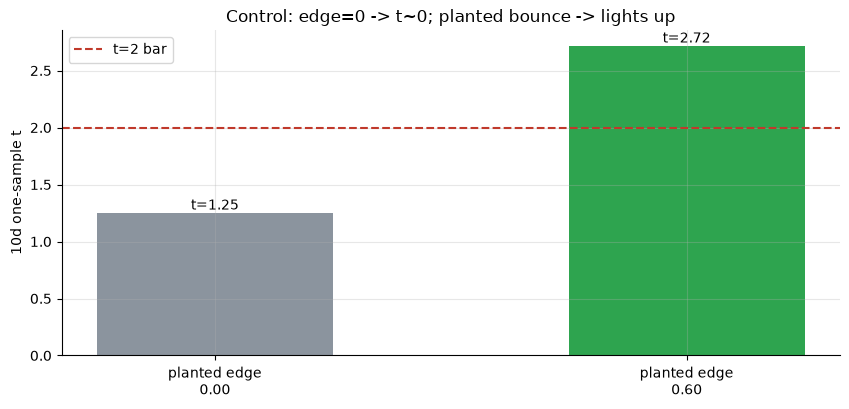

edge=0.00: n=353 panic=+30.3bps win=54% t=+1.25
edge=0.60: n=358 panic=+66.3bps win=59% t=+2.72


In [6]:
res = []
for edge in (0.0, 0.60):
    p, truth = data.synthetic_panel(edge=edge, seed=490, n_days=4000)
    trin = st.compute_trin(p); c = p[truth['traded']]['close']
    c = c[c.index.isin(trin.index)]; trin = trin[trin.index.isin(c.index)]
    e = st.panic_entries(trin, q=R['q']); s = st.summarize(st.forward_returns(c, e, 10))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('10d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} panic={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control averages to a coin across seeds (this seed lands at *t* = 1.25, sampling noise); a planted bounce reaches **t = 2.72** (win 59%). The detector works — so the weak real-tape result is an honest 'a little something', not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — the panic entry beats a drift-matched random baseline at every horizon (Δ = +29/+28/+33/+48 bps) and the timing placebo is significant (*p* ≤ 0.04) — a *real* effect. But the Welch *t* never clears 2 (max +1.53), so it's soft.
- **Tradability `FRAGILE`** — a ~25–30 bps premium over random that survives costs but rests on ~460 clustered crash entries and is mostly the generic volatility rebound. A lean, not a scalable stand-alone edge.
- **Forecasts turns? `MIXED`** — the timing placebo says the placement of high-TRIN days carries information (structure is real), but the harder vs-random test doesn't clinch it. Real structure, weak forecast.

## 6 · Could you trade it? — a lean, not a strategy

The panic premium is real but small (~30 bps over random) and statistically soft, and a large slice of it is the well-documented short-horizon volatility rebound that any 'buy the crash day' rule captures. Costs are negligible (1 bp round-trip), so friction isn't the killer — the killers are weak significance and *regime clustering*: the ~460 entries concentrate in a handful of crash episodes, so the effective independent sample is much smaller. TRIN earns a place as *one input* to a contrarian timer; as a stand-alone system it is too thin to size with confidence.

## 7 · Going further

- **Real exchange breadth.** Swap the 5-ETF proxy for genuine NYSE $ADV/$DECL/$UVOL/$DVOL; a 3000-issue TRIN may sharpen (or dilute) the signal. `data.load_basket` already wires a 10-name sector basket for anyone with a network connection.
- **Partial out the rebound.** Regress the panic return on a same-day-move control to see how much survives once 'I just bought a crash day' is removed — the cleanest test of whether TRIN's *volume normalisation* adds anything over raw drawdown.
- **Regime-aware errors.** Because entries cluster, block-bootstrap or HAC-on-overlap standard errors would widen the bands further — the honest *t* is likely *softer* still.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*